# Real World Classification

## Load data

Import the necessary libraries

In [17]:
# If you do not use colab. You should install these packages.
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install graphviz


[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip

[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip

[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip

[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip

[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [19]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


## Data Preprocessing

In [20]:
# 3(a) - reporting median and std before imputation
df_raw = pd.read_csv('data/NYCU_Iris.csv')
feature_cols_raw = [c for c in df_raw.columns if c not in ['Id', 'Species']]
for col in feature_cols_raw:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

missing_cols = [col for col in feature_cols_raw if df_raw[col].isnull().any()]
print("Columns with missing values:", missing_cols)
print("\n=== Before Imputation ===")
for col in missing_cols:
    print(f"{col}: median={df_raw[col].median():.4f}, std={df_raw[col].std():.4f}")

Columns with missing values: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'BranchLength']

=== Before Imputation ===
SepalLengthCm: median=6.3000, std=1.0371
SepalWidthCm: median=2.9000, std=0.3896
PetalLengthCm: median=5.0856, std=1.5828
PetalWidthCm: median=1.6000, std=0.7067
BranchLength: median=16.3000, std=1.0352


In [21]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    imputer = KNNImputer(n_neighbors=5)
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)

In [22]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


In [23]:
# 3(b) - reporting median and std after imputation
print("\n=== After KNN Imputation ===")
for col in missing_cols:
    print(f"{col}: median={df[col].median():.4f}, std={df[col].std():.4f}")


=== After KNN Imputation ===
SepalLengthCm: median=6.3000, std=1.0093
SepalWidthCm: median=2.9000, std=0.3724
PetalLengthCm: median=5.0357, std=1.5150
PetalWidthCm: median=1.7000, std=0.6946
BranchLength: median=16.3000, std=1.0110


## Data Exploration

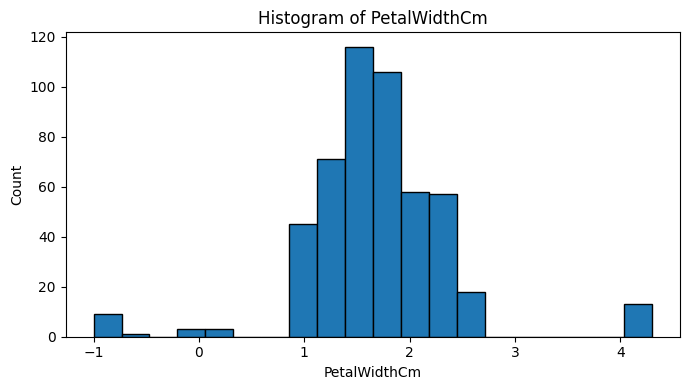

Feature with largest positive correlation:
feature      PetalWidthCompactness
pearson_r                  0.99167
Name: 26, dtype: object

Top 5 features with strongest negative correlation:
                  feature  pearson_r
11    SepalWidthMajorAxis  -0.096350
46        SepalGlossIndex  -0.095200
14  SepalWidthCompactness  -0.088496
16    SepalWidthCurvature  -0.081334
12    SepalWidthMinorAxis  -0.074392


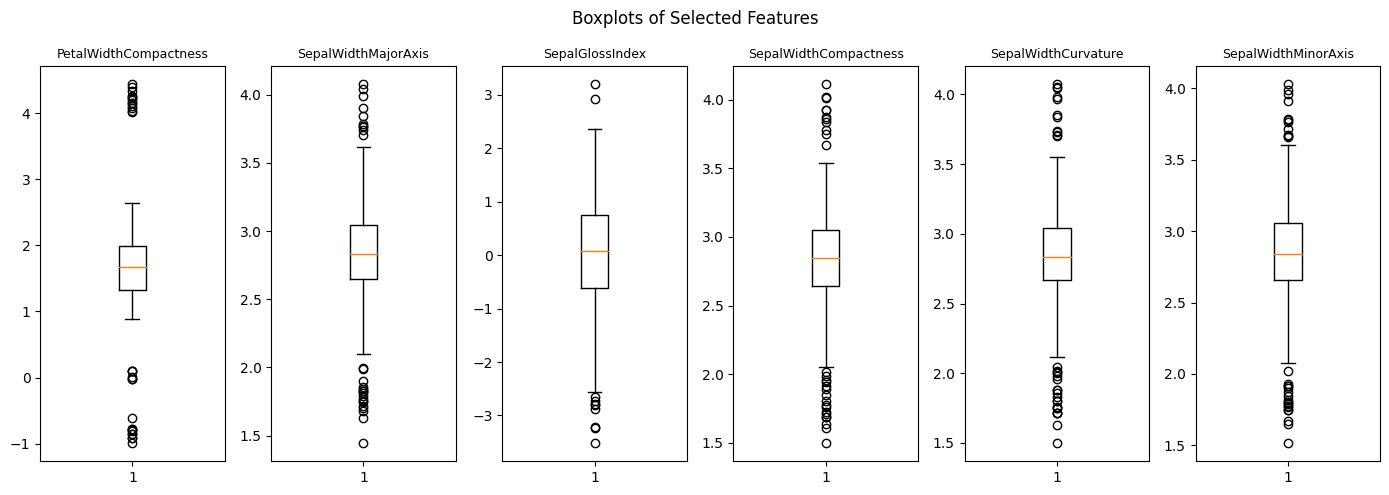

In [24]:
from sklearn.feature_selection import r_regression

# 4(a) — Histogram of PetalWidthCm
plt.figure(figsize=(7, 4))
plt.hist(df['PetalWidthCm'], bins=20, edgecolor='black')
plt.title('Histogram of PetalWidthCm')
plt.xlabel('PetalWidthCm')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
# Observation: likely bimodal (two clusters) — small-petal and large-petal species

# 4(b) — Feature with LARGEST POSITIVE correlation with PetalWidthCm
target = df['PetalWidthCm'].values
candidates = [c for c in feature_cols if c not in ['PetalWidthCm', 'Species', 'Id']]
X_candidates = df[candidates].values

correlations = r_regression(X_candidates, target)
corr_df = pd.DataFrame({'feature': candidates, 'pearson_r': correlations})
corr_df = corr_df.sort_values('pearson_r', ascending=False)

print("Feature with largest positive correlation:")
print(corr_df.iloc[0])

# 4(c) — Top 5 features with strongest NEGATIVE correlations
negative_corr = corr_df.sort_values('pearson_r', ascending=True)
top5_negative = negative_corr.head(5)
print("\nTop 5 features with strongest negative correlation:")
print(top5_negative)

# 4(d) — Boxplots for features from 4(b) and 4(c)
best_positive = corr_df.iloc[0]['feature']
top5_neg_features = top5_negative['feature'].tolist()
features_to_plot = [best_positive] + top5_neg_features

plt.figure(figsize=(14, 5))
for i, feat in enumerate(features_to_plot, 1):
    plt.subplot(1, len(features_to_plot), i)
    plt.boxplot(df[feat].dropna())
    plt.title(feat, fontsize=9)
plt.suptitle('Boxplots of Selected Features')
plt.tight_layout()
plt.show()

## Model Training

### Prepare the data

In [25]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!

50. Training loss: 0.6183886535310102, Val loss:0.6383381911771241
100. Training loss: 0.5960033921480784, Val loss:0.6229857283892484
150. Training loss: 0.5781690886526527, Val loss:0.6111796844177569
200. Training loss: 0.5636439627476499, Val loss:0.6019785825360592
250. Training loss: 0.5515861130769195, Val loss:0.5947349187857767
300. Training loss: 0.5414115554176107, Val loss:0.5889917649142379
350. Training loss: 0.5327055446405081, Val loss:0.5844187428740429
400. Training loss: 0.5251667000245236, Val loss:0.5807716266567299
450. Training loss: 0.5185712433977272, Val loss:0.5778662753932695
500. Training loss: 0.5127496761323889, Val loss:0.5755614147648993
550. Training loss: 0.5075712624849853, Val loss:0.5737469965121451
600. Training loss: 0.5029334978289509, Val loss:0.5723361523089564
650. Training loss: 0.49875481918863024, Val loss:0.571259514930716
700. Training loss: 0.4949694641429734, Val loss:0.5704611319860384
750. Training loss: 0.49152377948438897, Val loss

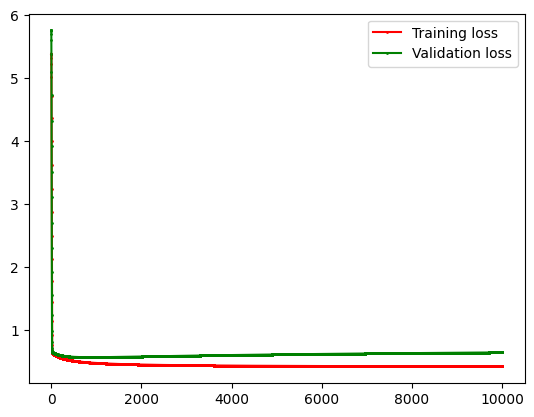

Model parameters (weights): [[-3.09226542]
 [ 0.81422629]
 [ 0.35178624]
 [-0.7609665 ]
 [ 0.86152155]
 [-0.01533802]
 [ 0.29669952]
 [-0.03629679]
 [ 0.20223017]
 [ 1.8869661 ]
 [ 0.87767537]
 [ 0.74544323]
 [ 1.16299519]
 [ 0.19552937]
 [-1.00811454]
 [-0.10050799]
 [ 1.60616526]
 [ 0.70302677]
 [ 0.15269826]
 [ 0.18948831]
 [ 0.26495978]
 [ 0.49098399]
 [-0.11040372]
 [ 0.66380585]
 [ 0.43424603]
 [ 2.06351944]
 [ 1.76565182]
 [ 1.74553348]
 [ 2.00502818]
 [ 1.80907373]
 [ 1.7727681 ]
 [-2.27530402]
 [ 1.42115829]
 [-0.39117344]
 [ 0.27016079]
 [-1.48784374]
 [ 0.60407509]
 [-1.09556673]
 [-3.03287109]
 [-0.45021112]
 [-1.22819914]
 [-0.42913274]
 [-0.96548124]
 [-1.23728785]
 [ 0.52211853]
 [-0.03098011]
 [ 0.01005535]
 [ 0.29405703]
 [-0.60621754]
 [-0.66869117]
 [-0.47178247]
 [ 0.33885952]
 [ 0.17406024]
 [-0.59406833]
 [-0.3958753 ]
 [ 0.48301625]
 [-0.85626669]
 [-1.22172831]
 [-0.30024527]
 [ 0.56252418]
 [-1.00901787]
 [ 0.747168  ]
 [ 0.62641196]
 [-1.6014551 ]
 [ 0.1372598

In [26]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='', reg_lambda=0.0)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

50. Training loss: 0.6183886535310102, Val loss:0.6383381911771241
100. Training loss: 0.5960033921480784, Val loss:0.6229857283892484
150. Training loss: 0.5781690886526527, Val loss:0.6111796844177569
200. Training loss: 0.5636439627476499, Val loss:0.6019785825360592
250. Training loss: 0.5515861130769195, Val loss:0.5947349187857767
300. Training loss: 0.5414115554176107, Val loss:0.5889917649142379
350. Training loss: 0.5327055446405081, Val loss:0.5844187428740429
400. Training loss: 0.5251667000245236, Val loss:0.5807716266567299
450. Training loss: 0.5185712433977272, Val loss:0.5778662753932695
500. Training loss: 0.5127496761323889, Val loss:0.5755614147648993
550. Training loss: 0.5075712624849853, Val loss:0.5737469965121451
600. Training loss: 0.5029334978289509, Val loss:0.5723361523089564
650. Training loss: 0.49875481918863024, Val loss:0.571259514930716
700. Training loss: 0.4949694641429734, Val loss:0.5704611319860384
750. Training loss: 0.49152377948438897, Val loss

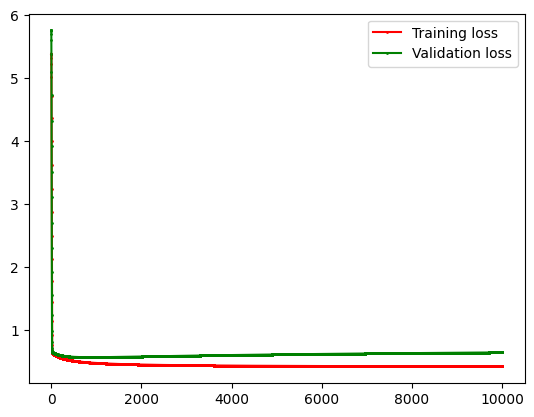

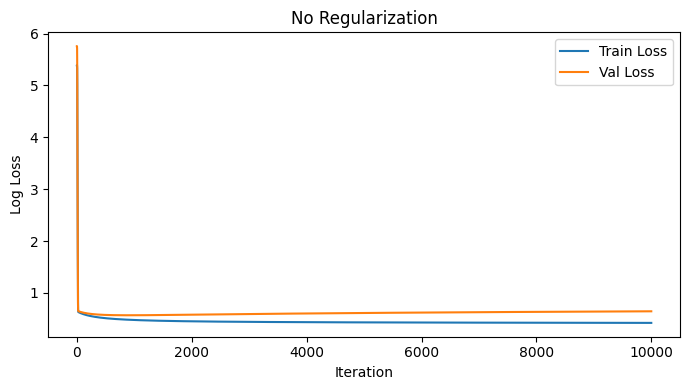

50. Training loss: 0.6183968442308057, Val loss:0.6383418749174559
100. Training loss: 0.5960218584459506, Val loss:0.6229937284988916
150. Training loss: 0.5781987940557217, Val loss:0.6111917862872271
200. Training loss: 0.5636852669117252, Val loss:0.6019940821319419
250. Training loss: 0.5516390786456719, Val loss:0.5947528491389577
300. Training loss: 0.5414760921827048, Val loss:0.5890110215795246
350. Training loss: 0.5327814781753895, Val loss:0.5844381571451082
400. Training loss: 0.5252538055110114, Val loss:0.5807900103412457
450. Training loss: 0.5186692635109195, Val loss:0.5778824491950174
500. Training loss: 0.5128583316269498, Val loss:0.5755742266452543
550. Training loss: 0.5076902593666242, Val loss:0.5737553335810299
600. Training loss: 0.5030625328026356, Val loss:0.5723389483402412
650. Training loss: 0.4988935840888995, Val loss:0.571255754814553
700. Training loss: 0.4951176496280415, Val loss:0.5704498539888322
750. Training loss: 0.4916810781087384, Val loss:0

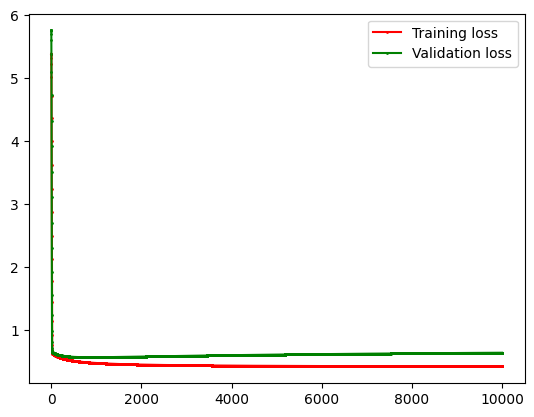

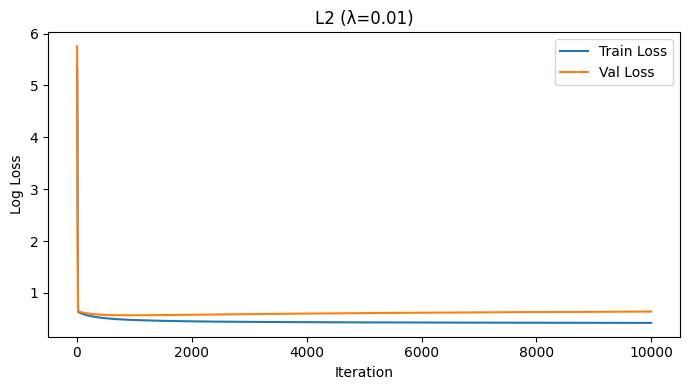

50. Training loss: 0.6192229675550639, Val loss:0.6387339171797571
100. Training loss: 0.5979091328910923, Val loss:0.6238920902494233
150. Training loss: 0.5812650420168968, Val loss:0.6126225576568589
200. Training loss: 0.5679827993268195, Val loss:0.6039318894908267
250. Training loss: 0.5571858255876309, Val loss:0.5971444430979668
300. Training loss: 0.5482708567526591, Val loss:0.59178857989705
350. Training loss: 0.5408117331839131, Val loss:0.5875271116871134
400. Training loss: 0.5344999386168847, Val loss:0.5841138047798571
450. Training loss: 0.5291070807888374, Val loss:0.5813654836364933
500. Training loss: 0.524460662779445, Val loss:0.5791436781671646
550. Training loss: 0.5204280628046019, Val loss:0.577342251554659
600. Training loss: 0.5169056942810414, Val loss:0.5758788683267105
650. Training loss: 0.5138115085968704, Val loss:0.57468898760961
700. Training loss: 0.5110797027848409, Val loss:0.5737215545999529
750. Training loss: 0.5086569127317132, Val loss:0.5729

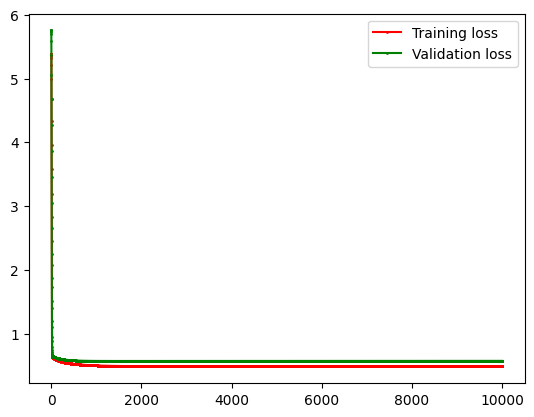

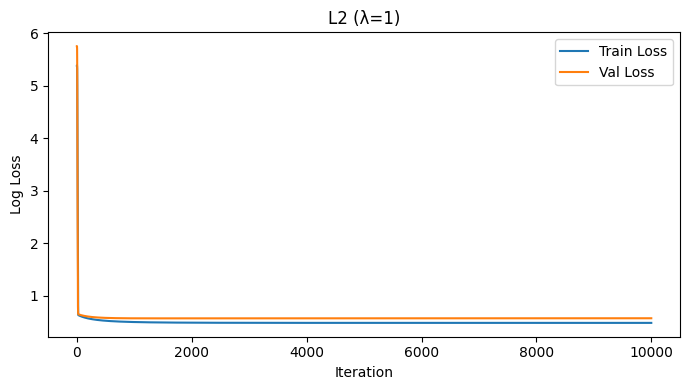

50. Training loss: 0.6737565170340649, Val loss:0.6828695995569816
100. Training loss: 0.6747289430162428, Val loss:0.6839071965242837
150. Training loss: 0.6747483271618208, Val loss:0.6839293732638189
200. Training loss: 0.6747487102403309, Val loss:0.6839298451300981
250. Training loss: 0.674748717829201, Val loss:0.6839298552460086
300. Training loss: 0.6747487179798805, Val loss:0.6839298554645057
350. Training loss: 0.6747487179828773, Val loss:0.6839298554692588
400. Training loss: 0.674748717982937, Val loss:0.6839298554693628
450. Training loss: 0.6747487179829381, Val loss:0.683929855469365
500. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
550. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
600. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
650. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
700. Training loss: 0.6747487179829382, Val loss:0.6839298554693651
750. Training loss: 0.6747487179829382, Val loss:0.6

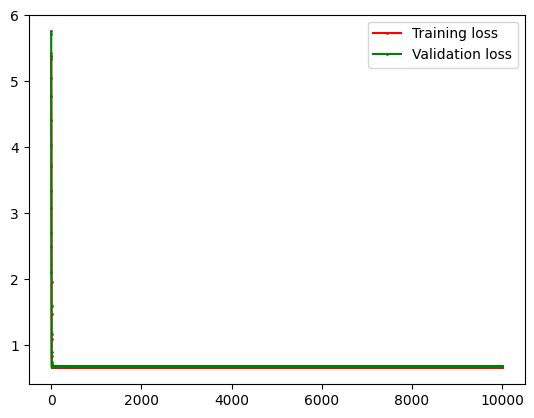

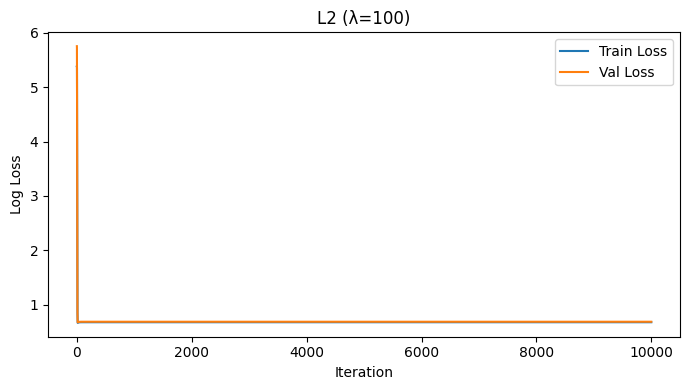

=== Test Set Evaluation ===

No Regularization
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


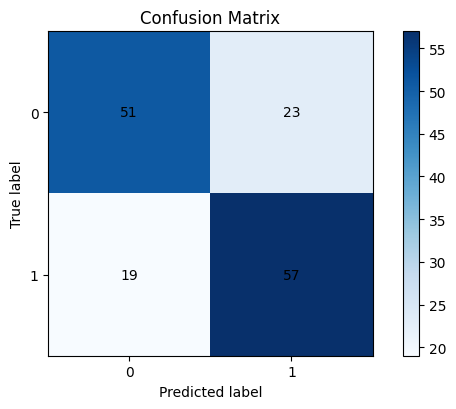


L2 (λ=0.01)
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


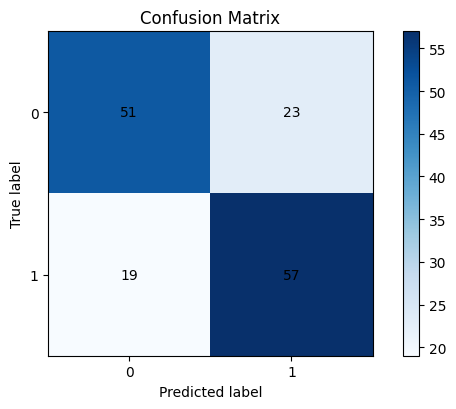


L2 (λ=1)
Accuracy  : 0.7400
Precision : 0.7342
Recall    : 0.7632
F1-score  : 0.7484


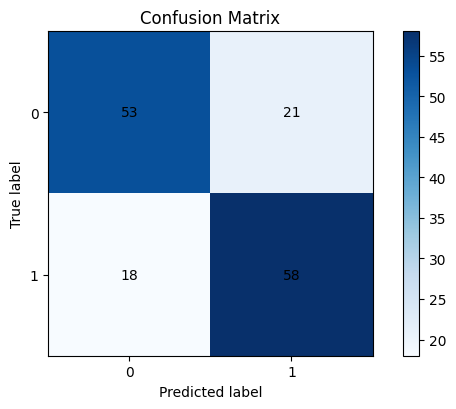


L2 (λ=100)
Accuracy  : 0.5067
Precision : 0.5067
Recall    : 1.0000
F1-score  : 0.6726


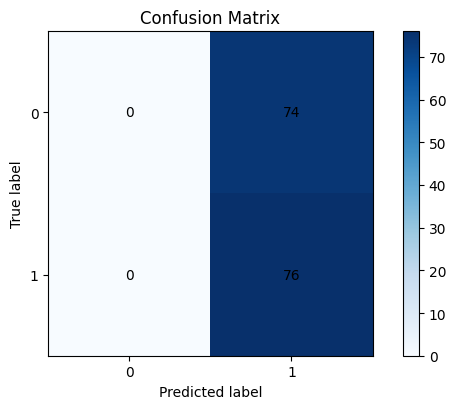

In [27]:
from model.linear_model import LinearModel
from model.metrics import logloss, evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.activations import sigmoid

seed = 40
configs = [
    {'reg_type': '',   'reg_lambda': 0.0,  'label': 'No Regularization'},
    {'reg_type': 'l2', 'reg_lambda': 0.01, 'label': 'L2 (λ=0.01)'},
    {'reg_type': 'l2', 'reg_lambda': 1,    'label': 'L2 (λ=1)'},
    {'reg_type': 'l2', 'reg_lambda': 100,  'label': 'L2 (λ=100)'},
]

trained_models = {}

for cfg in configs:
    np.random.seed(seed)
    model = LinearModel(dim=X_train.shape[1], is_reg=False,
                        loss_fn=logloss, act_fn=sigmoid, grad_fn=logloss_sigmoid_grad)
    model.fit(X_train, y_train, lr=0.1, n_iteration=10000,
              val_ratio=0.2, reg_type=cfg['reg_type'], reg_lambda=cfg['reg_lambda'])

    # 5(a) - Plot loss curve
    plt.figure(figsize=(7, 4))
    plt.plot(model.train_losses, label='Train Loss')
    plt.plot(model.val_losses, label='Val Loss')
    plt.title(cfg['label'])
    plt.xlabel('Iteration')
    plt.ylabel('Log Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

    trained_models[cfg['label']] = model

# 5(b) - Evaluate all configs on test set
print("=== Test Set Evaluation ===\n")
for cfg in configs:
    model = trained_models[cfg['label']]
    y_pred = model.predict(X_test)
    evaluate_binary_classifier(y_test, y_pred, title=cfg['label'])
    print()

## Metrics

Model Evaluation
Accuracy  : 0.5067
Precision : 0.5067
Recall    : 1.0000
F1-score  : 0.6726


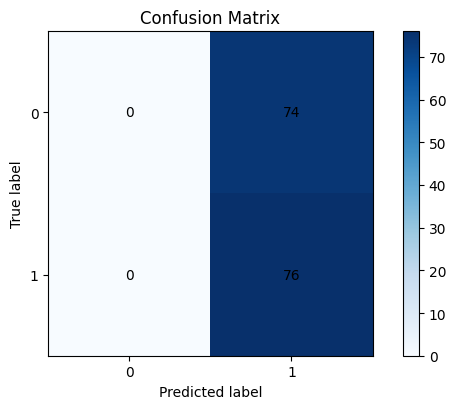

{'Accuracy': 0.5066666666666667,
 'Precision': 0.5066666666666667,
 'Recall': 1.0,
 'F1-score': 0.6725663716814159}

In [28]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

y_pred = model.predict(X_test)
evaluate_binary_classifier(y_test, y_pred)

=== Test Set Evaluation ===

No Regularization
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


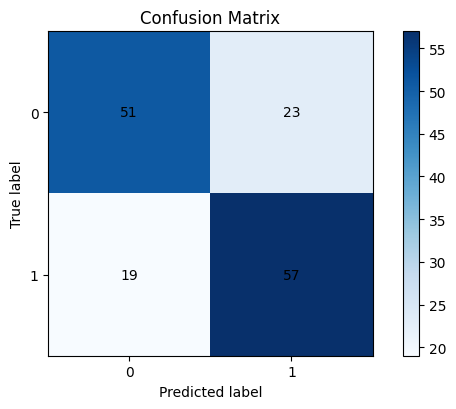


L2 (λ=0.01)
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


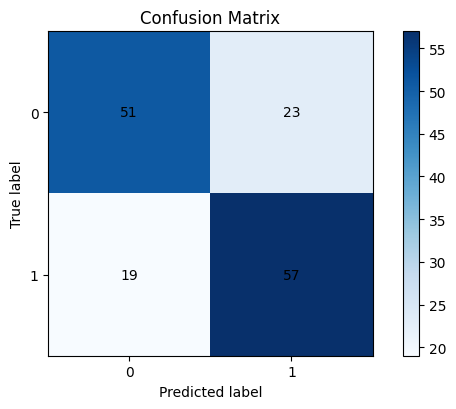


L2 (λ=1)
Accuracy  : 0.7400
Precision : 0.7342
Recall    : 0.7632
F1-score  : 0.7484


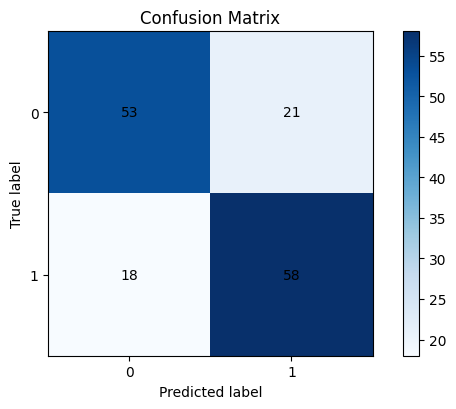


L2 (λ=100)
Accuracy  : 0.5067
Precision : 0.5067
Recall    : 1.0000
F1-score  : 0.6726


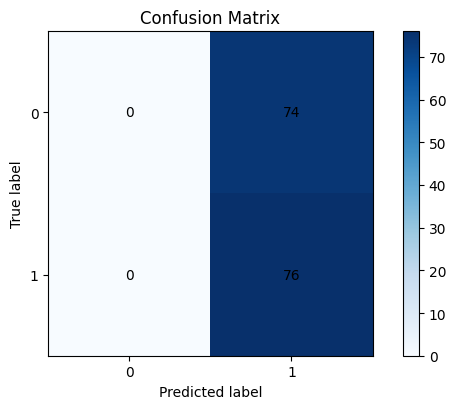

In [29]:
print("=== Test Set Evaluation ===\n")
for cfg in configs:
    model = trained_models[cfg['label']]
    y_pred = model.predict(X_test)
    evaluate_binary_classifier(y_test, y_pred, title=cfg['label'])
    print()

In [36]:
!ls

Linear_Regression.ipynb         data
Logistic_Regression.ipynb       mobile_price.csv
README.md                       model
Real_World_Classification.ipynb


In [ ]:
Assignment 2 Task 1

In [39]:
import importlib
import model.linear_model
importlib.reload(model.linear_model)
from model.linear_model import LinearModel

In [46]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score
from model.linear_model import LinearModel
from model.metrics import logloss, evaluate_binary_classifier
from model.gradients import logloss_sigmoid_grad
from model.activations import sigmoid
from tqdm.notebook import tqdm

seed = 40
lr_options = [0.005, 0.01, 0.1, 0.5]
lambda_options = [1.0, 2.0, 4.0, 8.0]
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=40)

grid_scores = {}
combos = [(lr, lam) for lr in lr_options for lam in lambda_options]

for lr, lam in tqdm(combos, desc="Cross-Validation Grid Search"):
    clf = LinearModel(
        is_reg=False,
        loss_fn=logloss,
        grad_fn=logloss_sigmoid_grad,
        act_fn=sigmoid,
        lr=lr,
        reg_type='l2',
        reg_lambda=lam,
        n_iteration=1000,
        val_ratio=0.0,
        random_state=seed,
        verbose=False,
        plot_curve=False
    )
    fold_scores = cross_val_score(
        clf, X_train, y_train,
        cv=KFold(n_splits=5, shuffle=True, random_state=40),
        scoring='accuracy'
    )
    grid_scores[(lr, lam)] = fold_scores.mean()

# create and display 4x4 table
score_table = pd.DataFrame(
    index=[f'lr={v}' for v in lr_options],
    columns=[f'λ={v}' for v in lambda_options]
)
for lr in lr_options:
    for lam in lambda_options:
        score_table.loc[f'lr={lr}', f'λ={lam}'] = round(grid_scores[(lr, lam)], 4)

print("5-Fold CV Average Accuracy (4x4 Table):")
print(score_table)

Cross-Validation Grid Search:   0%|          | 0/16 [00:00<?, ?it/s]

5-Fold CV Average Accuracy (4x4 Table):
           λ=1.0   λ=2.0   λ=4.0   λ=8.0
lr=0.005  0.6657  0.6686  0.6714  0.6771
lr=0.01   0.6886  0.6886  0.6943  0.6714
lr=0.1    0.7257    0.74    0.74  0.7257
lr=0.5    0.7343  0.7229  0.5429  0.4629


Top 2 hyperparameter combinations:

lr=0.1, λ=2.0 → CV Accuracy=0.7400
Test Results — lr=0.1, λ=2.0
Accuracy  : 0.7600
Precision : 0.7381
Recall    : 0.8158
F1-score  : 0.7750


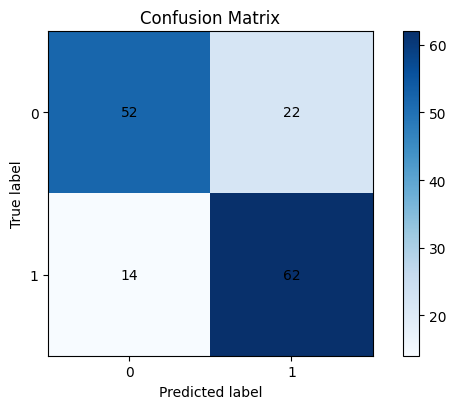


lr=0.1, λ=4.0 → CV Accuracy=0.7400
Test Results — lr=0.1, λ=4.0
Accuracy  : 0.7400
Precision : 0.7176
Recall    : 0.8026
F1-score  : 0.7578


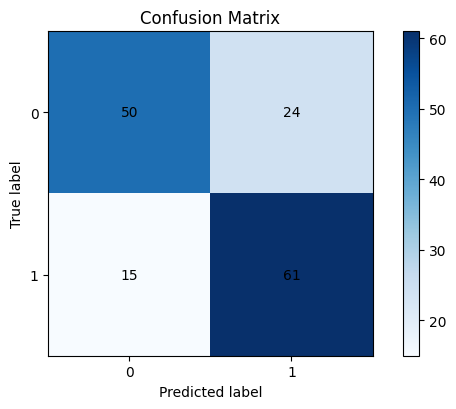

In [47]:
# 1(b) - select top 2 and evaluate on test set
ranked = sorted(grid_scores.items(), key=lambda x: x[1], reverse=True)
top2_combos = ranked[:2]

print("Top 2 hyperparameter combinations:\n")
for (lr, lam), score in top2_combos:
    print(f"lr={lr}, λ={lam} → CV Accuracy={score:.4f}")
    np.random.seed(seed)
    best_clf = LinearModel(
        is_reg=False,
        loss_fn=logloss,
        grad_fn=logloss_sigmoid_grad,
        act_fn=sigmoid,
        lr=lr,
        reg_type='l2',
        reg_lambda=lam,
        n_iteration=1000,
        val_ratio=0.2,
        random_state=seed,
        verbose=False,
        plot_curve=False
    )
    best_clf.fit(X_train, y_train)
    preds = best_clf.predict(X_test)
    evaluate_binary_classifier(y_test, preds, title=f'Test Results — lr={lr}, λ={lam}')
    print()